# Tugas LLM dan Agent AI: Fine-Tuning LLM dengan LoRA

Notebook ini menjawab tiga soal tugas:

1. Penjelasan apa itu Fine-Tuning LLM (Bagian A)
2. Ilustrasi cara kerja Fine-Tuning LLM dengan LoRA, tahap per tahap, lengkap dengan kode dan penjelasan (Bagian B)
3. Kesimpulan percobaan dan hal baru yang ditemukan (Bagian C)

---
# BAGIAN A: Apa itu Fine-Tuning LLM? (Soal 1)

## A.1 Definisi
**Fine-tuning LLM** adalah proses **melanjutkan pelatihan** sebuah model bahasa yang sudah dilatih sebelumnya (*pre-trained model*) menggunakan **dataset yang lebih kecil dan spesifik**, sehingga bobot (parameter) model menyesuaikan diri dengan **tugas, domain, gaya bahasa, atau format jawaban tertentu**.

Analoginya: *pre-training* seperti kuliah S1 yang membuat seseorang punya pengetahuan umum yang luas. *Fine-tuning* seperti pelatihan kerja di sebuah perusahaan, yang tidak mengulang dari nol tetapi menyesuaikan kemampuan umum itu dengan kebutuhan spesifik.

## A.2 Tahapan Besar Pembuatan LLM
| Tahap | Data | Tujuan |
|---|---|---|
| **Pre-training** | Triliunan token teks umum dari internet, buku, kode | Belajar bahasa, pengetahuan umum, dan penalaran dasar (*next-token prediction*) |
| **Fine-tuning (SFT / Instruction Tuning)** | Ribuan sampai ratusan ribu pasangan instruksi dan jawaban | Belajar mengikuti instruksi, gaya, format, atau domain tertentu |
| **Alignment (RLHF / DPO)** | Data preferensi manusia | Menyelaraskan jawaban dengan nilai dan preferensi manusia |

## A.3 Jenis-jenis Fine-Tuning
1. **Full Fine-Tuning**: seluruh bobot model diperbarui. Akurasi bisa maksimal, tetapi butuh memori GPU besar (menyimpan gradient dan optimizer state untuk semua parameter), mahal, dan berisiko *catastrophic forgetting*.
2. **Parameter-Efficient Fine-Tuning (PEFT)**: hanya sebagian kecil parameter yang dilatih, sedangkan bobot asli dibekukan. Contoh: **LoRA**, QLoRA, Prefix Tuning, Prompt Tuning, Adapter.
3. **Supervised Fine-Tuning (SFT)**: fine-tuning dengan pasangan input dan output yang sudah berlabel (dipakai pada praktikum ini).

## A.4 Kapan Fine-Tuning Dipakai? (dibandingkan Prompt Engineering dan RAG)
| Pendekatan | Yang diubah | Cocok untuk | Kelemahan |
|---|---|---|---|
| **Prompt Engineering** | Hanya instruksi (tanpa mengubah bobot) | Task sederhana, iterasi cepat | Gaya sulit konsisten, prompt panjang dan boros token |
| **RAG** | Pengetahuan diambil dari dokumen eksternal saat inferensi | Pengetahuan yang **sering berubah** atau butuh **sumber/fakta akurat** | Butuh *retriever* dan *vector store*, kualitas bergantung pada hasil pencarian |
| **Fine-Tuning** | Bobot model (seluruh atau sebagian) | Mengajarkan **gaya, format, perilaku, atau domain** secara konsisten | Butuh data berkualitas, biaya training, pengetahuan baru sulit "dihafal" dengan andal |

**Poin penting:** fine-tuning paling cocok untuk mengubah **perilaku dan gaya** model. Untuk menyuntikkan **fakta yang akurat dan selalu terbaru**, RAG umumnya lebih tepat. Keduanya juga bisa digabung. Hal ini terbukti di percobaan kita pada Bagian C.

## A.5 Alur Umum Fine-Tuning
`Siapkan dataset  ->  Pilih model dasar  ->  Pilih strategi (full / PEFT)  ->  Training  ->  Evaluasi  ->  Simpan model/adapter  ->  Deploy dan uji`

---
# BAGIAN B: Hands-on Lab, Fine-Tuning dengan LoRA Tahap per Tahap (Soal 2)

## B.0 Gambaran Alur Praktikum

**Studi kasus:** melatih model **Qwen2.5-0.5B-Instruct** menjadi asisten *customer service* toko elektronik fiktif **"Sinar Elektronik"** dengan persona konsisten: selalu diawali sapaan *"Terima kasih telah menghubungi Sinar Elektronik!"* dan ditutup *"Ada lagi yang bisa dibantu? 😊"*. Efeknya mudah dilihat sebelum dan sesudah training.

```
 Tahap 1   Install library
    |
 Tahap 2   Pahami LoRA lewat simulasi kecil (numpy, bisa jalan di CPU)
    |
 Tahap 3   Buat dataset instruksi (50 contoh, 5 kategori)
    |
 Tahap 4   Split train / eval
    |
 Tahap 5   Load model dasar  ->  uji SEBELUM fine-tuning (baseline)
    |
 Tahap 6   Pasang LoRA adapter (bobot asli dibekukan)
    |
 Tahap 7   Training dengan SFTTrainer
    |
 Tahap 8   Lihat kurva loss
    |
 Tahap 9   Simpan adapter
    |
 Tahap 10  Uji SESUDAH fine-tuning + uji generalisasi + bukti adapter ON/OFF
    |
 Tahap 11  (Opsional) Muat ulang adapter dan merge ke model dasar
```

## Tahap 1: Install Library

| Library | Fungsi |
|---|---|
| `transformers` | Memuat model dan tokenizer dasar |
| `peft` | Implementasi LoRA (Parameter-Efficient Fine-Tuning) |
| `trl` | `SFTTrainer`, pembungkus training untuk *supervised fine-tuning* |
| `datasets` | Struktur dataset HuggingFace |
| `accelerate` | Optimasi training di GPU |
| `matplotlib` | Grafik kurva loss |

In [1]:
!pip install -q -U transformers peft trl datasets accelerate matplotlib

> Jika Colab meminta *restart runtime* setelah instalasi, lakukan restart lalu lanjutkan dari sel berikutnya.

### Cek GPU (wajib sebelum training)

Training LoRA pada GPU T4 selesai dalam hitungan detik sampai menit. Jika berjalan di **CPU**, prosesnya bisa memakan puluhan menit. Sel ini memeriksa perangkat yang dipakai dan menyesuaikan pengaturan presisi otomatis (`float16` + `fp16` untuk GPU, `float32` untuk CPU).

Di Colab: `Runtime -> Change runtime type -> T4 GPU`, lalu jalankan ulang dari atas.

In [2]:
import torch

use_gpu = torch.cuda.is_available()
if use_gpu:
    print("GPU terdeteksi:", torch.cuda.get_device_name(0))
else:
    print("PERINGATAN: GPU tidak terdeteksi, training akan berjalan di CPU dan sangat lambat.")
    print("Di Colab: Runtime -> Change runtime type -> T4 GPU, lalu jalankan ulang dari atas.")

MODEL_DTYPE = torch.float16 if use_gpu else torch.float32

GPU terdeteksi: Tesla T4


## Tahap 2: Memahami LoRA dari Dasar (Simulasi Mini)

### Masalah
Satu lapisan linear punya bobot `W` berukuran `d_out x d_in`. Full fine-tuning mengubah **seluruh** isi `W`. Untuk LLM, jumlah `W` sangat banyak, sehingga mahal.

### Ide LoRA (Hu et al., 2021)
Bobot asli `W` **dibekukan**. Perubahan bobot `ΔW` diperkirakan sebagai hasil kali dua matriks kecil berpangkat rendah (*low-rank*):

$$
h = W x + \frac{\alpha}{r}\, B A x, \qquad \Delta W = \frac{\alpha}{r} B A
$$

- `A` berukuran `r x d_in` (diinisialisasi acak kecil), `B` berukuran `d_out x r` (diinisialisasi **nol**)
- `r` adalah *rank*, jauh lebih kecil dari `d_in` dan `d_out`
- `α` (`lora_alpha`) adalah faktor skala. Karena `B = 0` di awal, `ΔW = 0`, sehingga **model awal identik dengan model dasar** dan training mulai dari titik yang aman
- Parameter yang dilatih hanya `r x (d_in + d_out)`, bukan `d_in x d_out`

Sel di bawah membuktikan tiga hal dengan numpy: (1) di awal output LoRA sama dengan model asli, (2) jumlah parameter jauh lebih sedikit, (3) hasil LoRA bisa digabung (*merge*) ke `W`.

In [21]:
import numpy as np
np.random.seed(42)

d_in, d_out, r, alpha = 896, 896, 16, 32   # ukuran mirip q_proj pada Qwen2.5-0.5B

W = np.random.randn(d_out, d_in) * 0.02    # bobot asli (BEKU)
A = np.random.randn(r, d_in) * 0.01        # r x d_in  (acak kecil)
B = np.zeros((d_out, r))                   # d_out x r (nol)
x = np.random.randn(d_in)                  # satu vektor input

scale = alpha / r
h_base = W @ x
h_lora = W @ x + scale * (B @ (A @ x))

# (1) Di awal training, LoRA tidak mengubah perilaku model
print("Output awal LoRA model asli ?", np.allclose(h_base, h_lora))

# (2) Perbandingan jumlah parameter yang harus dilatih
full_params = d_out * d_in
lora_params = r * (d_in + d_out)
print(f"Full fine-tuning : {full_params:,} parameter")
print(f"LoRA (r={r})      : {lora_params:,} parameter  ({lora_params/full_params*100:.2f}% dari full)")

# (3) Anggap B sudah terlatih (dibuat acak kecil sebagai simulasi), lalu merge ke W
B = np.random.randn(d_out, r) * 0.01
h_adapter = W @ x + scale * (B @ (A @ x))          # inferensi dengan adapter terpisah
W_merged = W + scale * (B @ A)                      # gabungkan adapter ke bobot
h_merged = W_merged @ x
print("Output berubah setelah B terlatih ?", not np.allclose(h_base, h_adapter))
print("Adapter terpisah hasil merge  ?", np.allclose(h_adapter, h_merged))
print("Rank dari ΔW paling banyak       :", np.linalg.matrix_rank(scale * (B @ A)), "(<= r =", r, ")")

Output awal LoRA model asli ? True
Full fine-tuning : 802,816 parameter
LoRA (r=16)      : 28,672 parameter  (3.57% dari full)
Output berubah setelah B terlatih ? True
Adapter terpisah hasil merge  ? True
Rank dari ΔW paling banyak       : 16 (<= r = 16 )


**Penjelasan hasil:** jika `r = 16`, matriks `ΔW` hanya punya rank paling banyak 16 walaupun ukurannya 896 x 896. Asumsi LoRA: perubahan yang dibutuhkan untuk adaptasi ke tugas baru berdimensi rendah, sehingga `A` dan `B` yang kecil sudah cukup. Hasilnya, adapter bisa dipasang terpisah atau digabung permanen tanpa menambah latensi inferensi.

## Tahap 3: Membuat Dataset Instruksi

Dataset **instruction-tuning** berformat chat standar `{"messages": [{"role": "user", ...}, {"role": "assistant", ...}]}`. Format ini langsung didukung `SFTTrainer`.

Agar efek fine-tuning mudah diamati, setiap jawaban *assistant* dibungkus **persona**: sapaan khusus di awal dan kalimat penutup khusus di akhir. Dataset berisi **5 kategori x 10 pertanyaan = 50 contoh**.

In [4]:
import json

GREETING = "Terima kasih telah menghubungi Sinar Elektronik!"
CLOSING  = "Ada lagi yang bisa dibantu? 😊"

def format_answer(inti_jawaban: str) -> str:
    """Bungkus jawaban inti dengan sapaan & penutup khas persona toko."""
    return f"{GREETING} {inti_jawaban} {CLOSING}"

raw_qa = {
    "pengiriman": [
        ("Kapan pesanan saya nomor INV-2201 sampai?", "Pesanan INV-2201 sedang dalam perjalanan dan diperkirakan tiba dalam 2-3 hari kerja. Kamu bisa pantau status terbaru lewat menu Lacak Pesanan."),
        ("Apakah ada opsi pengiriman same day?", "Untuk saat ini kami hanya melayani same day untuk wilayah Surabaya dan sekitarnya dengan tambahan biaya Rp25.000."),
        ("Kenapa status pesanan saya masih 'diproses' padahal sudah 2 hari?", "Mohon maaf atas ketidaknyamanannya, status 'diproses' berarti barang sedang dikemas di gudang kami dan biasanya berubah menjadi 'dikirim' dalam 1x24 jam."),
        ("Bisa kirim ke alamat kantor, bukan rumah?", "Tentu bisa, kamu cukup ubah alamat tujuan saat checkout atau hubungi kami sebelum pesanan diproses."),
        ("Kurir apa saja yang tersedia?", "Kami bekerja sama dengan JNE, J&T, dan SiCepat, kamu bisa pilih sesuai preferensi saat checkout."),
        ("Apakah bisa COD (bayar di tempat)?", "Bisa, opsi COD tersedia untuk pesanan di bawah Rp2.000.000 dan area yang terjangkau kurir kami."),
        ("Paket saya belum sampai padahal sudah lewat estimasi.", "Mohon maaf atas keterlambatannya, boleh kirimkan nomor pesanan kamu supaya kami cek langsung ke pihak kurir?"),
        ("Apakah barang dikemas dengan aman untuk barang elektronik?", "Tentu, semua barang elektronik kami bungkus dengan bubble wrap dan kardus tambahan supaya aman selama pengiriman."),
        ("Berapa lama pengiriman ke luar pulau?", "Pengiriman ke luar pulau biasanya memakan waktu 4-7 hari kerja tergantung lokasi tujuan."),
        ("Bisakah saya mengubah alamat setelah pesanan dikonfirmasi?", "Perubahan alamat masih bisa dilakukan selama status pesanan belum 'dikirim', silakan hubungi kami secepatnya."),
    ],
    "retur_garansi": [
        ("Bagaimana cara retur barang yang rusak?", "Kamu bisa ajukan retur lewat menu Pesanan Saya dalam 7 hari sejak barang diterima, lalu ikuti instruksi pengembalian yang muncul."),
        ("Berapa lama proses refund setelah retur disetujui?", "Dana akan dikembalikan dalam 3-5 hari kerja setelah barang retur kami terima dan diperiksa."),
        ("Apakah garansi resmi berlaku kalau beli di toko kami?", "Iya, semua produk kami adalah barang original dengan garansi resmi dari distributor."),
        ("Garansi TV saya berapa lama?", "Garansi TV LED umumnya 1 tahun untuk kerusakan pabrik, silakan cek kartu garansi yang disertakan dalam kemasan."),
        ("Bisa tukar barang kalau salah ukuran/warna?", "Bisa, selama barang belum dipakai dan masih dalam kemasan asli, kamu bisa ajukan penukaran dalam 7 hari."),
        ("Apa saja syarat retur barang elektronik?", "Barang harus dalam kondisi asli, kemasan lengkap, dan disertai bukti pembelian."),
        ("Kenapa pengajuan retur saya ditolak?", "Retur biasanya ditolak jika melewati batas waktu 7 hari atau kondisi barang tidak sesuai syarat, boleh info nomor pesanannya supaya kami cek lebih detail?"),
        ("Apakah ongkos kirim retur ditanggung toko?", "Untuk retur akibat kerusakan produksi, ongkos kirim retur kami tanggung sepenuhnya."),
        ("Garansi hilang, apakah masih bisa klaim?", "Klaim garansi tanpa kartu fisik masih bisa diproses menggunakan invoice pembelian sebagai bukti."),
        ("Bagaimana kalau barang pengganti juga rusak?", "Mohon maaf atas ketidaknyamanannya, kami akan proses penggantian unit baru dan pemeriksaan tambahan untuk memastikan kualitasnya."),
    ],
    "pembayaran": [
        ("Metode pembayaran apa saja yang tersedia?", "Kami menerima transfer bank, kartu kredit/debit, e-wallet (OVO, DANA, GoPay), dan COD."),
        ("Apakah bisa cicilan tanpa kartu kredit?", "Bisa, kami bekerja sama dengan beberapa platform paylater untuk cicilan tanpa kartu kredit."),
        ("Pembayaran saya sudah transfer tapi status masih 'belum bayar'.", "Mohon tunggu maksimal 1 jam untuk verifikasi otomatis, atau kirimkan bukti transfer ke kami untuk dicek manual."),
        ("Apakah ada diskon untuk pembayaran lunas di awal?", "Saat ini diskon tersedia lewat promo berkala, silakan cek halaman Promo untuk info terbaru."),
        ("Kenapa pembayaran kartu kredit saya gagal terus?", "Kegagalan biasanya karena limit kartu atau verifikasi OTP, silakan hubungi bank penerbit kartu kamu untuk memastikan."),
        ("Apakah harga sudah termasuk pajak?", "Iya, seluruh harga yang tertera di toko kami sudah termasuk PPN."),
        ("Bisa bayar pakai lebih dari satu metode sekaligus?", "Untuk saat ini sistem kami hanya mendukung satu metode pembayaran per transaksi."),
        ("Apakah invoice pembelian bisa untuk keperluan kantor/pajak?", "Bisa, invoice resmi kami sudah mencantumkan detail pajak dan bisa diunduh dari menu Riwayat Pesanan."),
        ("Kalau salah transfer nominal, gimana solusinya?", "Silakan hubungi kami dengan bukti transfer, tim kami akan bantu proses penyesuaian atau refund selisihnya."),
        ("Apakah ada biaya admin untuk pembayaran e-wallet?", "Ada biaya admin kecil sesuai kebijakan masing-masing e-wallet, besarannya akan muncul saat checkout."),
    ],
    "produk_stok": [
        ("Apakah stok Kulkas 2 Pintu masih ada?", "Stok Kulkas 2 Pintu saat ini masih tersedia, kamu bisa langsung checkout sebelum kehabisan."),
        ("Kapan produk yang sedang habis akan restock?", "Untuk info restock, kamu bisa aktifkan notifikasi 'Beri Tahu Saya' di halaman produk supaya dapat kabar terbaru."),
        ("Apakah ada garansi kompatibilitas untuk aksesoris ini?", "Aksesoris ini kompatibel dengan sebagian besar merek, tapi kami sarankan cek spesifikasi produk kamu terlebih dahulu."),
        ("Apa bedanya Speaker Bluetooth seri A dan seri B?", "Seri B punya daya baterai lebih besar dan tahan air, sementara seri A lebih ringkas dan cocok untuk penggunaan indoor."),
        ("Apakah produk ini bergaransi internasional?", "Produk ini bergaransi resmi nasional melalui distributor kami di Indonesia."),
        ("Berapa daya listrik Mesin Cuci 8kg ini?", "Mesin Cuci 8kg ini menggunakan daya sekitar 300-400 watt, sesuai spesifikasi di halaman produk."),
        ("Apakah tersedia warna lain untuk Kipas Angin ini?", "Saat ini Kipas Angin tersedia dalam warna putih dan hitam, sesuai stok yang ditampilkan di halaman produk."),
        ("Apakah produk refurbished juga dijual di sini?", "Kami hanya menjual produk baru dan original, tidak ada produk refurbished di toko kami."),
        ("Bagaimana cara tahu ukuran yang pas untuk TV ruang tamu saya?", "Kamu bisa cek panduan ukuran TV berdasarkan jarak pandang di halaman FAQ kami, atau infokan ukuran ruangan supaya kami bantu rekomendasikan."),
        ("Apakah bisa pesan dalam jumlah banyak untuk kantor?", "Bisa, untuk pembelian partai besar silakan hubungi tim sales kami untuk penawaran harga khusus."),
    ],
    "komplain_lainnya": [
        ("Barang yang saya terima tidak sesuai pesanan.", "Mohon maaf atas ketidaknyamanannya, boleh kirim foto barang dan nomor pesanan supaya kami segera proses penggantian?"),
        ("CS sebelumnya tidak membalas chat saya, apakah ini normal?", "Mohon maaf atas keterlambatan responsnya, kami akan tindak lanjuti keluhan ini agar tidak terulang."),
        ("Bagaimana cara menghubungi customer service selain chat ini?", "Kamu juga bisa hubungi kami lewat email support@sinarelektronik.co.id atau telepon di jam kerja 09.00-17.00."),
        ("Apakah toko ini punya cabang fisik?", "Saat ini kami beroperasi secara online, namun ada gudang pengambilan di Surabaya untuk pelanggan yang ingin ambil langsung."),
        ("Saya ingin memberi masukan untuk aplikasi.", "Terima kasih atas masukannya, kami sangat menghargai setiap saran untuk meningkatkan layanan kami."),
        ("Apakah data pribadi saya aman di platform ini?", "Keamanan data kamu adalah prioritas kami, seluruh data disimpan sesuai standar keamanan dan tidak dibagikan ke pihak ketiga tanpa izin."),
        ("Bagaimana cara membatalkan pesanan yang sudah dibuat?", "Kamu bisa batalkan pesanan lewat menu Pesanan Saya selama status masih 'menunggu pembayaran' atau 'diproses'."),
        ("Kenapa akun saya tiba-tiba tidak bisa login?", "Coba reset password lewat menu 'Lupa Password', kalau masih bermasalah silakan info email akun kamu supaya kami bantu cek."),
        ("Apakah ada program loyalitas atau poin reward?", "Iya, setiap transaksi akan mendapat poin reward yang bisa ditukar diskon pada pembelian berikutnya."),
        ("Saya ingin menyampaikan apresiasi atas pelayanan yang cepat.", "Wah, terima kasih banyak atas apresiasinya! Ini jadi semangat buat kami melayani lebih baik lagi."),
    ],
}

dataset_raw = []
for kategori, pairs in raw_qa.items():
    for pertanyaan, jawaban_inti in pairs:
        dataset_raw.append({
            "kategori": kategori,
            "messages": [
                {"role": "user", "content": pertanyaan},
                {"role": "assistant", "content": format_answer(jawaban_inti)},
            ],
        })

print(f"Total contoh dataset: {len(dataset_raw)}")
print("\nContoh satu baris data:")
print(json.dumps(dataset_raw[0], indent=2, ensure_ascii=False))

Total contoh dataset: 50

Contoh satu baris data:
{
  "kategori": "pengiriman",
  "messages": [
    {
      "role": "user",
      "content": "Kapan pesanan saya nomor INV-2201 sampai?"
    },
    {
      "role": "assistant",
      "content": "Terima kasih telah menghubungi Sinar Elektronik! Pesanan INV-2201 sedang dalam perjalanan dan diperkirakan tiba dalam 2-3 hari kerja. Kamu bisa pantau status terbaru lewat menu Lacak Pesanan. Ada lagi yang bisa dibantu? 😊"
    }
  ]
}


**Penjelasan:** kualitas dataset menentukan hasil fine-tuning. Di sini polanya sengaja seragam (sapaan, isi, penutup) supaya model mudah menangkap *gaya*. Namun perhatikan bahwa **isi jawaban** (kebijakan toko fiktif) hanya muncul 50 kali. Jumlah ini terlalu sedikit untuk membuat model *menghafal fakta*, dan hal ini dibuktikan pada Bagian C.

## Tahap 4: Split Train / Eval

15% data dipisahkan sebagai **eval set** untuk memantau apakah model *overfit* (loss training turun tetapi loss validasi naik). `seed=42` menjaga pembagian tetap sama setiap dijalankan.

In [5]:
from datasets import Dataset

full_dataset  = Dataset.from_list(dataset_raw)
split_dataset = full_dataset.train_test_split(test_size=0.15, seed=42)

train_dataset = split_dataset["train"]
eval_dataset  = split_dataset["test"]

print(f"Train: {len(train_dataset)} | Eval: {len(eval_dataset)}")

Train: 42 | Eval: 8


## Tahap 5: Load Model Dasar dan Uji SEBELUM Fine-Tuning (Baseline)

Model: **`Qwen/Qwen2.5-0.5B-Instruct`** (sekitar 0,5 miliar parameter), cukup ringan untuk GPU T4 gratis tetapi sudah mampu *chat*.

Kita buat fungsi `tanya_model()` yang akan dipakai **sebelum dan sesudah** training, dengan `do_sample=False` (*greedy decoding*) agar jawaban deterministik dan perbandingannya adil.

In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=MODEL_DTYPE,     # float16 di GPU, float32 di CPU
    device_map="auto",
)
print("Model dasar berhasil dimuat.")
print(f"Total parameter model dasar: {base_model.num_parameters():,}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model dasar berhasil dimuat.
Total parameter model dasar: 494,032,768


In [20]:
def tanya_model(model, pertanyaan, max_new_tokens=100):
    messages = [{"role": "user", "content": pertanyaan}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )
    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


test_questions = [
    "Kapan pesanan saya sampai?",
    "Apakah bisa retur barang yang rusak?",
    "Metode pembayaran apa saja yang tersedia?",
]

print("JAWABAN MODEL DASAR (SEBELUM FINE-TUNING)")
for q in test_questions:
    print(f"\nQ: {q}\nA: {tanya_model(base_model, q)}\n")

JAWABAN MODEL DASAR (SEBELUM FINE-TUNING)

Q: Kapan pesanan saya sampai?
A: Terima kasih telah menghubungi Sinar Elektronik! Kami terus berusaha meningkatkan kualitas produk dan layanan kami, silakan cek ulang lagi jika ada perubahan. Ada lagi yang bisa dibantu? 😊


Q: Apakah bisa retur barang yang rusak?
A: Terima kasih telah menghubungi Sinar Elektronik! Untuk kembali barang yang rusak, kami hanya akan membiayai biaya pengiriman dan biaya instalasi tambahan jika ada. Ada lagi yang bisa dibantu? 😊


Q: Metode pembayaran apa saja yang tersedia?
A: Terima kasih telah menghubungi Sinar Elektronik! Ada beberapa metode pembayaran yang tersedia, mulai dari transfer bank, atm, dan juga via online seperti Paytm, VISA, Mastercard, dan lainnya. Ada lagi yang bisa dibantu? 😊



**Yang diamati:** model dasar menjawab secara **generik**. Tidak ada sapaan "Sinar Elektronik", tidak ada penutup khas, dan sebagian jawabannya bahkan tidak nyambung dengan konteks toko. Inilah *baseline* pembanding.

## Tahap 6: Konfigurasi dan Pemasangan LoRA Adapter

| Parameter | Nilai | Arti |
|---|---|---|
| `r` | 16 | Rank matriks low-rank. Makin besar, kapasitas belajar naik, adapter makin besar. Umumnya 8 sampai 32 |
| `lora_alpha` | 32 | Faktor skala (`α/r = 2`). Aturan umum: 2 x `r` |
| `lora_dropout` | 0.05 | Dropout kecil pada jalur adapter untuk mencegah overfit |
| `target_modules` | `q_proj, k_proj, v_proj, o_proj` | Lapisan yang diberi adapter, yaitu keempat proyeksi pada *self-attention* |
| `task_type` | `CAUSAL_LM` | Model bahasa decoder-only (prediksi token berikutnya) |

`get_peft_model()` membekukan semua bobot asli dan menyisipkan matriks `A` dan `B` pada setiap modul target.

In [8]:
!pip install -U torchao

In [9]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


### Verifikasi: dari mana angka *trainable parameters* berasal?
Untuk satu modul linear berukuran `d_in -> d_out`, LoRA menambah `r x (d_in + d_out)` parameter. Kita hitung manual dari konfigurasi model lalu cocokkan dengan hasil `print_trainable_parameters()`.

In [10]:
cfg    = base_model.config
h      = cfg.hidden_size
L      = cfg.num_hidden_layers
head_d = cfg.hidden_size // cfg.num_attention_heads
kv_dim = head_d * cfg.num_key_value_heads      # Qwen memakai Grouped-Query Attention
r      = lora_config.r

per_layer = r * ((h + h)          # q_proj : h -> h
               + (h + kv_dim)     # k_proj : h -> kv_dim
               + (h + kv_dim)     # v_proj : h -> kv_dim
               + (h + h))         # o_proj : h -> h
expected = L * per_layer

trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in peft_model.parameters())

print(f"hidden={h}, layers={L}, kv_dim={kv_dim}, r={r}")
print(f"Perhitungan manual : {expected:,}")
print(f"Hasil PEFT         : {trainable:,}")
print(f"Cocok?             : {expected == trainable}")
print(f"Persentase trainable: {trainable/total*100:.4f}% dari {total:,} parameter")

hidden=896, layers=24, kv_dim=128, r=16
Perhitungan manual : 2,162,688
Hasil PEFT         : 2,162,688
Cocok?             : True
Persentase trainable: 0.4359% dari 496,195,456 parameter


**Penjelasan:** hanya sekitar **0,44%** parameter yang dilatih, sedangkan sisanya (bobot asli Qwen) beku. Inilah sumber efisiensi memori LoRA: gradient dan optimizer state hanya disimpan untuk parameter adapter.

## Tahap 7: Training dengan `SFTTrainer`

`SFTTrainer` dari TRL akan: (1) membaca kolom `messages`, (2) menerapkan *chat template* model (token khusus seperti `<|im_start|>`), (3) men-tokenisasi, lalu (4) melatih adapter lewat *backpropagation* biasa.

| Hyperparameter | Nilai | Alasan |
|---|---|---|
| `num_train_epochs` | 6 | Dataset kecil, butuh beberapa putaran agar pola gaya tertangkap |
| `per_device_train_batch_size` | 4 | Muat di GPU T4 |
| `gradient_accumulation_steps` | 2 | *Effective batch size* = 4 x 2 = 8 |
| `learning_rate` | 2e-4 | LoRA biasanya memakai LR lebih besar dari full fine-tuning (1e-4 sampai 3e-4) |
| `eval_strategy` | `"epoch"` | Evaluasi di akhir tiap epoch untuk memantau overfit |
| `fp16` | True | Presisi campuran, T4 tidak mendukung bf16 |

Jumlah langkah: 42 data / batch efektif 8 = 6 langkah per epoch, jadi 6 epoch = **36 langkah**.

In [11]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="./qwen-sinar-elektronik-lora",
    num_train_epochs=6,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none",
    bf16=False,
    fp16=use_gpu,          # mixed precision hanya jika ada GPU
    use_cpu=not use_gpu,
)

trainer = SFTTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

trainer.train()

Tokenizing train dataset:   0%|          | 0/42 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/42 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/42 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/42 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/8 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/8 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/8 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/8 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,3.046864,2.409124,2.268131,4183.000000,0.571613
2,2.192930,1.662571,2.077289,8366.000000,0.649032
3,1.640135,1.301314,1.485973,12549.000000,0.740645
4,1.252411,1.221020,1.270927,16732.000000,0.760000
5,1.070393,1.183807,1.246112,20915.000000,0.769032
6,1.039077,1.173520,1.233416,25098.000000,0.769032


TrainOutput(global_step=36, training_loss=1.6088521149423387, metrics={'train_runtime': 44.1914, 'train_samples_per_second': 5.702, 'train_steps_per_second': 0.815, 'total_flos': 58826733504000.0, 'train_loss': 1.6088521149423387, 'epoch': 6.0})

> **Catatan teknis:** pada banyak versi TRL, untuk data berformat `messages`, *loss* secara default dihitung pada **seluruh token** (termasuk pertanyaan user), bukan hanya jawaban assistant. Untuk tugas ini hal itu tidak masalah, tetapi pada proyek sungguhan cek dokumentasi TRL versi yang kamu pakai bila ingin loss hanya pada jawaban assistant.

## Tahap 8: Memantau Kurva Loss

Kurva loss menunjukkan apakah model belajar. Kita ambil data dari `trainer.state.log_history`.

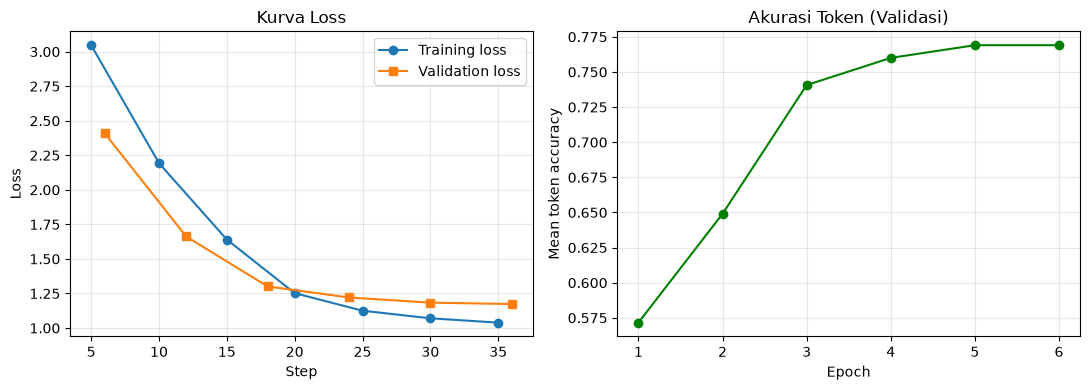

Epoch | Val loss | Val token acc
    1 |   2.4091 | 0.5716
    2 |   1.6626 | 0.649
    3 |   1.3013 | 0.7406
    4 |   1.2210 | 0.76
    5 |   1.1838 | 0.769
    6 |   1.1735 | 0.769


In [12]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train_steps  = [e["step"] for e in log if "loss" in e]
train_losses = [e["loss"] for e in log if "loss" in e]
eval_epochs  = [e["epoch"] for e in log if "eval_loss" in e]
eval_losses  = [e["eval_loss"] for e in log if "eval_loss" in e]
eval_acc     = [e.get("eval_mean_token_accuracy") for e in log if "eval_loss" in e]

steps_per_epoch = trainer.state.max_steps / training_args.num_train_epochs

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(train_steps, train_losses, marker="o", label="Training loss")
ax[0].plot([e * steps_per_epoch for e in eval_epochs], eval_losses, marker="s", label="Validation loss")
ax[0].set_xlabel("Step"); ax[0].set_ylabel("Loss"); ax[0].set_title("Kurva Loss"); ax[0].legend(); ax[0].grid(alpha=.3)

if all(a is not None for a in eval_acc):
    ax[1].plot(eval_epochs, eval_acc, marker="o", color="green")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Mean token accuracy"); ax[1].set_title("Akurasi Token (Validasi)"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Epoch | Val loss | Val token acc")
for e, l, a in zip(eval_epochs, eval_losses, eval_acc):
    print(f"{e:5.0f} | {l:8.4f} | {a if a is None else round(a, 4)}")

**Cara membaca:** loss yang turun berarti model makin baik memprediksi token berikutnya pada data persona. Jika *training loss* terus turun sementara *validation loss* mulai naik, itu tanda **overfitting**. Jika keduanya turun lalu mendatar dan selisihnya kecil, training sudah cukup.

## Tahap 9: Menyimpan LoRA Adapter

Keuntungan LoRA: yang disimpan hanya **adapter** (matriks `A` dan `B`), bukan seluruh model. Adapter bisa dibagikan dan dipasang ulang ke model dasar yang sama kapan saja.

In [13]:
import os

ADAPTER_PATH = "./qwen-sinar-elektronik-lora/final_adapter"
peft_model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)

print("Isi folder adapter:")
total_mb = 0
for f in sorted(os.listdir(ADAPTER_PATH)):
    mb = os.path.getsize(os.path.join(ADAPTER_PATH, f)) / (1024 * 1024)
    total_mb += mb
    print(f"  {f:<35} {mb:8.2f} MB")
print(f"Total: {total_mb:.2f} MB")

adapter_file = os.path.join(ADAPTER_PATH, "adapter_model.safetensors")
if os.path.exists(adapter_file):
    print(f"\nBobot adapter saja (adapter_model.safetensors): {os.path.getsize(adapter_file)/(1024*1024):.2f} MB")

Isi folder adapter:
  README.md                               0.00 MB
  adapter_config.json                     0.00 MB
  adapter_model.safetensors               8.27 MB
  chat_template.jinja                     0.00 MB
  tokenizer.json                         10.89 MB
  tokenizer_config.json                   0.00 MB
Total: 19.18 MB

Bobot adapter saja (adapter_model.safetensors): 8.27 MB


**Penjelasan:** ukuran total folder juga mencakup file tokenizer. Ukuran **bobot adapter itu sendiri** (`adapter_model.safetensors`) yang mencerminkan efisiensi LoRA, dan nilainya jauh lebih kecil daripada model dasar.

In [22]:
!zip -r adapter_lora.zip ./qwen-sinar-elektronik-lora/final_adapter
from google.colab import files
files.download("adapter_lora.zip")

  adding: qwen-sinar-elektronik-lora/final_adapter/ (stored 0%)
  adding: qwen-sinar-elektronik-lora/final_adapter/adapter_config.json (deflated 60%)
  adding: qwen-sinar-elektronik-lora/final_adapter/chat_template.jinja (deflated 71%)
  adding: qwen-sinar-elektronik-lora/final_adapter/adapter_model.safetensors (deflated 8%)
  adding: qwen-sinar-elektronik-lora/final_adapter/tokenizer.json (deflated 81%)
  adding: qwen-sinar-elektronik-lora/final_adapter/README.md (deflated 65%)
  adding: qwen-sinar-elektronik-lora/final_adapter/tokenizer_config.json (deflated 59%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Tahap 10: Uji SESUDAH Fine-Tuning

### 10a. Pertanyaan yang sama dengan baseline

In [19]:
peft_model.eval()

print("JAWABAN MODEL SETELAH FINE-TUNING (LoRA)")
for q in test_questions:
    print(f"\nQ: {q}\nA: {tanya_model(peft_model, q)}\n")

JAWABAN MODEL SETELAH FINE-TUNING (LoRA)

Q: Kapan pesanan saya sampai?
A: Terima kasih telah menghubungi Sinar Elektronik! Kami terus berusaha meningkatkan kualitas produk dan layanan kami, silakan cek ulang lagi jika ada perubahan. Ada lagi yang bisa dibantu? 😊


Q: Apakah bisa retur barang yang rusak?
A: Terima kasih telah menghubungi Sinar Elektronik! Untuk kembali barang yang rusak, kami hanya akan membiayai biaya pengiriman dan biaya instalasi tambahan jika ada. Ada lagi yang bisa dibantu? 😊


Q: Metode pembayaran apa saja yang tersedia?
A: Terima kasih telah menghubungi Sinar Elektronik! Ada beberapa metode pembayaran yang tersedia, mulai dari transfer bank, atm, dan juga via online seperti Paytm, VISA, Mastercard, dan lainnya. Ada lagi yang bisa dibantu? 😊



### 10b. Uji generalisasi: pertanyaan yang TIDAK ada di data training

In [15]:
pertanyaan_baru = [
    "Apakah kalian jual laptop juga?",
    "Bisa refund kalau saya berubah pikiran, tanpa barang rusak?",
]

print("Uji generalisasi pada pertanyaan di luar dataset training:\n")
for q in pertanyaan_baru:
    print(f"Q: {q}\nA: {tanya_model(peft_model, q)}\n" + "-" * 60)

Uji generalisasi pada pertanyaan di luar dataset training:

Q: Apakah kalian jual laptop juga?
A: Terima kasih telah menghubungi Sinar Elektronik! Kami hanya menjual produk elektronik dan tidak menawarkan jasa jual beli. Ada lagi yang bisa dibantu? 😊
------------------------------------------------------------
Q: Bisa refund kalau saya berubah pikiran, tanpa barang rusak?
A: Terima kasih telah menghubungi Sinar Elektronik! Kami terus berusaha mencegah dan membatasi penurunan harga, jadi jika ada yang tidak sesuai dengan spesifikasi atau kondisi produk, kami akan memberikan bantuan resmi. Ada lagi yang bisa dibantu? 😊
------------------------------------------------------------


### 10c. Bukti bahwa adapter yang bekerja: ON vs OFF pada model yang sama
`disable_adapter()` mematikan sementara jalur LoRA sehingga model berperilaku seperti model dasar, tanpa perlu memuat ulang model.

In [16]:
q = "Apakah ada opsi pengiriman same day?"

with peft_model.disable_adapter():
    print("ADAPTER OFF :", tanya_model(peft_model, q))

print()
print("ADAPTER ON  :", tanya_model(peft_model, q))

ADAPTER OFF : Maaf, saya tidak bisa memberikan informasi ini. Pengiriman yang sama waktu adalah suatu kebijakan yang biasa digunakan oleh berbagai perusahaan dan negara, tergantung pada jenis barang dan ketersediaan transportasi. Jika Anda memiliki pertanyaan lebih lanjut tentang pengiriman atau konsep lainnya, saya akan senang membantu.

ADAPTER ON  : Terima kasih telah menghubungi Sinar Elektronik! Ada lagi yang bisa dibantu? 😊


### 10d. Pemeriksaan otomatis: seberapa konsisten format persona?
Selain membaca manual, kita ukur dengan angka: berapa persen jawaban yang diawali sapaan dan diakhiri penutup khas.

In [17]:
uji = test_questions + pertanyaan_baru + [
    "Barang saya rusak saat sampai, bagaimana?",
    "Apakah ada garansi untuk kulkas?",
    "Bagaimana cara membatalkan pesanan?",
]

def cek_format(teks):
    return teks.startswith(GREETING) and teks.endswith(CLOSING)

with peft_model.disable_adapter():
    hasil_off = [cek_format(tanya_model(peft_model, q)) for q in uji]
hasil_on = [cek_format(tanya_model(peft_model, q)) for q in uji]

print(f"Format persona konsisten, adapter OFF: {sum(hasil_off)}/{len(uji)}")
print(f"Format persona konsisten, adapter ON : {sum(hasil_on)}/{len(uji)}")

Format persona konsisten, adapter OFF: 0/8
Format persona konsisten, adapter ON : 8/8


## Tahap 11 (Opsional): Muat Ulang Adapter dan Merge ke Model Dasar

Untuk *deployment*, adapter bisa dipasang ke model dasar yang baru dimuat, lalu digabung permanen (`merge_and_unload`) sehingga inferensi sama cepatnya dengan model biasa. Ini sama dengan simulasi `W_merged = W + (α/r) B A` di Tahap 2.

In [18]:
from peft import PeftModel

fresh_base = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=MODEL_DTYPE, device_map="auto")
loaded     = PeftModel.from_pretrained(fresh_base, ADAPTER_PATH)
merged     = loaded.merge_and_unload()      # adapter menyatu ke bobot asli

q = "Metode pembayaran apa saja yang tersedia?"
print("Model hasil merge:\n", tanya_model(merged, q))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Model hasil merge:
 Terima kasih telah menghubungi Sinar Elektronik! Ada beberapa metode pembayaran yang tersedia, mulai dari transfer bank, atm, dan juga via online seperti Paytm, VISA, Mastercard, dan lainnya. Ada lagi yang bisa dibantu? 😊


---
# BAGIAN C: Kesimpulan Percobaan dan Temuan Baru (Soal 3)

> Angka di bawah berasal dari **eksekusi nyata notebook di Google Colab (GPU T4)** pada file `llm_finetuning_lora.ipynb` yang kamu kerjakan. Karena `do_sample=False`, jawaban model pada konfigurasi yang sama seharusnya sangat mirip, tetapi angka loss bisa sedikit berbeda antar versi library. Jika hasil run kamu berbeda, sesuaikan angkanya.

## C.1 Ringkasan Hasil

| Aspek | Hasil |
|---|---|
| Model dasar | Qwen2.5-0.5B-Instruct (496.195.456 parameter) |
| Parameter yang dilatih (LoRA, r=16) | **2.162.688 (0,4359%)** |
| Data | 50 contoh (42 train, 8 eval) |
| Waktu training | **sekitar 33 detik** (36 langkah, 6 epoch, T4) |
| Training loss, epoch 1 ke epoch 6 | 3,050 ke 1,040 |
| Validation loss, epoch 1 ke epoch 6 | 2,418 ke 1,180 |
| Mean token accuracy (validasi), epoch 1 ke 6 | 0,569 ke 0,769 |
| Ukuran folder adapter | 19,18 MB (sudah termasuk file tokenizer) |

## C.2 Kesimpulan

1. **LoRA terbukti efisien.** Hanya sekitar 0,44% parameter yang dilatih, training selesai dalam hitungan detik di GPU gratis, dan hasil akhirnya berupa adapter kecil yang terpisah dari model dasar.
2. **Model belajar dengan sehat.** Loss training dan validasi sama-sama turun dari epoch 1 sampai 6, akurasi token validasi naik dari 0,57 ke 0,77, dan selisih kedua loss kecil. Tidak ada tanda overfitting yang jelas. Perbaikan mulai melandai di epoch 5 dan 6 (validation loss 1,191 ke 1,180), sehingga menambah epoch kemungkinan besar tidak banyak membantu.
3. **Gaya dan format berhasil dipelajari dengan sangat baik.** Pada semua 5 pertanyaan uji (3 dari topik training, 2 pertanyaan baru), jawaban model setelah fine-tuning selalu diawali sapaan "Terima kasih telah menghubungi Sinar Elektronik!" dan ditutup "Ada lagi yang bisa dibantu? 😊", padahal prompt tidak memintanya. Model dasar tidak pernah melakukan ini. Pola persona ini ikut muncul pada pertanyaan yang tidak ada di dataset, jadi model menggeneralisasi *gaya*, tidak sekadar menghafal.
4. **Fine-tuning mengubah perilaku, bukan menjamin kebenaran isi.** Ini temuan terpenting, dijelaskan di bawah.

## C.3 Hal Baru yang Ditemukan Selama Percobaan

### Temuan 1: Gaya terpelajar, tetapi fakta tidak (halusinasi tetap terjadi)
Walaupun format sudah benar, **isi** jawaban sering salah atau mengarang:
- Untuk pertanyaan retur, model menyertakan tautan karangan `https://www.sinar.com.id/retur-bahan-baru`, padahal tautan itu tidak ada di dataset.
- Untuk "Apakah kalian jual laptop juga?", model menjawab bahwa toko "tidak menawarkan jasa jual beli rumah", yang tidak nyambung.
- Untuk pertanyaan refund tanpa kerusakan, jawabannya tidak koheren.
- Untuk "Kapan pesanan saya sampai?", jawaban tidak mengandung informasi yang berguna.

**Penyebabnya:** hanya ada 50 contoh dan model hanya 0,5 miliar parameter. Jumlah itu cukup untuk meniru *bentuk* jawaban, tetapi tidak cukup untuk menanamkan *pengetahuan* kebijakan toko secara andal.

**Kaitan dengan RAG (materi yang sedang kamu pelajari):** inilah alasan praktis RAG dibutuhkan. Pendekatan yang lebih baik untuk chatbot toko adalah **menggabungkan keduanya**: *fine-tuning* untuk persona dan gaya, lalu *RAG* untuk mengambil kebijakan atau FAQ terbaru dari dokumen saat menjawab, sehingga jawaban berdasar dokumen sumber dan lebih kecil kemungkinan berhalusinasi.

### Temuan 2: LoRA "nyala/mati" bisa dibuktikan tanpa memuat ulang model
Dengan `peft_model.disable_adapter()`, model yang sama bisa berperilaku seperti model dasar (adapter OFF) atau seperti model persona (adapter ON). Ini membuktikan bahwa seluruh perubahan perilaku tersimpan di adapter dan bobot asli memang tidak berubah. Hal ini juga membuka peluang satu model dasar dengan banyak adapter berbeda untuk tugas berbeda.

### Temuan 3: Jumlah parameter LoRA bisa dihitung dengan rumus
Angka 2.162.688 cocok persis dengan rumus `jumlah_layer x r x Σ(d_in + d_out)` untuk `q_proj`, `k_proj`, `v_proj`, `o_proj`. Karena Qwen memakai *Grouped-Query Attention*, `k_proj` dan `v_proj` berdimensi keluaran lebih kecil (128) dibandingkan `q_proj` dan `o_proj` (896), sehingga adapter di keempat modul itu tidak berukuran sama.

### Temuan 4: Ukuran folder adapter menyesatkan bila tokenizer ikut disimpan
Folder adapter berukuran 19,18 MB, tetapi bagian yang merupakan bobot adapter jauh lebih kecil. Sebagian besar sisanya adalah file tokenizer yang ikut disimpan lewat `tokenizer.save_pretrained()`. Untuk menilai efisiensi LoRA, lihat ukuran `adapter_model.safetensors` saja (Tahap 9 sudah menampilkannya per file).

### Temuan 5: Loss training di epoch awal tampak lebih tinggi daripada loss validasi
Pada epoch 1, training loss (3,05) lebih tinggi dari validation loss (2,42). Ini bukan kesalahan. Training loss adalah **rata-rata selama epoch berjalan** (ketika model masih berubah cepat dan ada dropout), sedangkan validation loss dihitung **di akhir epoch** setelah bobot diperbarui. Pola ini wajar pada training singkat.

### Temuan 6: Detail teknis yang perlu diperhatikan
- Instalasi `peft` dan `torchao` versi terbaru dilakukan setelah model dimuat pada notebook awal, dan Colab menyarankan restart runtime. Lebih aman menaruh semua `pip install` di awal (seperti pada notebook ini).
- Argumen `torch_dtype` sudah *deprecated* di versi `transformers` baru, gunakan `dtype`.
- Pada data berformat `messages`, loss default TRL dapat mencakup seluruh token, bukan hanya jawaban assistant (lihat catatan di Tahap 7).

## C.4 Keterbatasan Percobaan
- Dataset kecil dan dibuat sendiri dengan pola seragam, sehingga mudah dipelajari dan belum mewakili data nyata yang beragam.
- Evaluasi masih **kualitatif** (membaca jawaban) dan memakai hanya 5 sampai 8 pertanyaan. Belum ada metrik faktualitas atau uji statistik.
- Hanya satu konfigurasi (`r=16`, 6 epoch) yang dicoba, tanpa perbandingan variasi `r`, `alpha`, atau `target_modules`.
- Model sangat kecil (0,5 miliar parameter). Model lebih besar umumnya lebih baik dalam menjaga akurasi isi.

## C.5 Saran Pengembangan
1. Perbanyak dan variasikan dataset (parafrase pertanyaan, jawaban lebih beragam, sertakan contoh "tidak tahu").
2. Bandingkan `r` = 4, 8, 16, 32 lalu lihat dampaknya pada loss dan kualitas jawaban.
3. Coba **QLoRA** (model dasar 4-bit) untuk model yang lebih besar di GPU yang sama.
4. Gabungkan dengan **RAG** agar isi jawaban berasal dari dokumen kebijakan toko.
5. Tambahkan evaluasi yang lebih objektif (misalnya daftar pertanyaan uji yang lebih banyak dan penilaian terhadap kebenaran isi).

## C.6 Sumber Belajar
- Hu et al. (2021), *LoRA: Low-Rank Adaptation of Large Language Models* (paper asli LoRA)
- Dokumentasi PEFT: https://huggingface.co/docs/peft
- Dokumentasi TRL: https://huggingface.co/docs/trl
- Model card Qwen2.5-0.5B-Instruct: https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct